--- Generating Comparative Chart: History vs 18 Scenarios vs LSTM ---
Success! Comparative chart saved at: E:\Projetos\ABMS-WP\figuras\figure-result-simulation-fig10.pdf


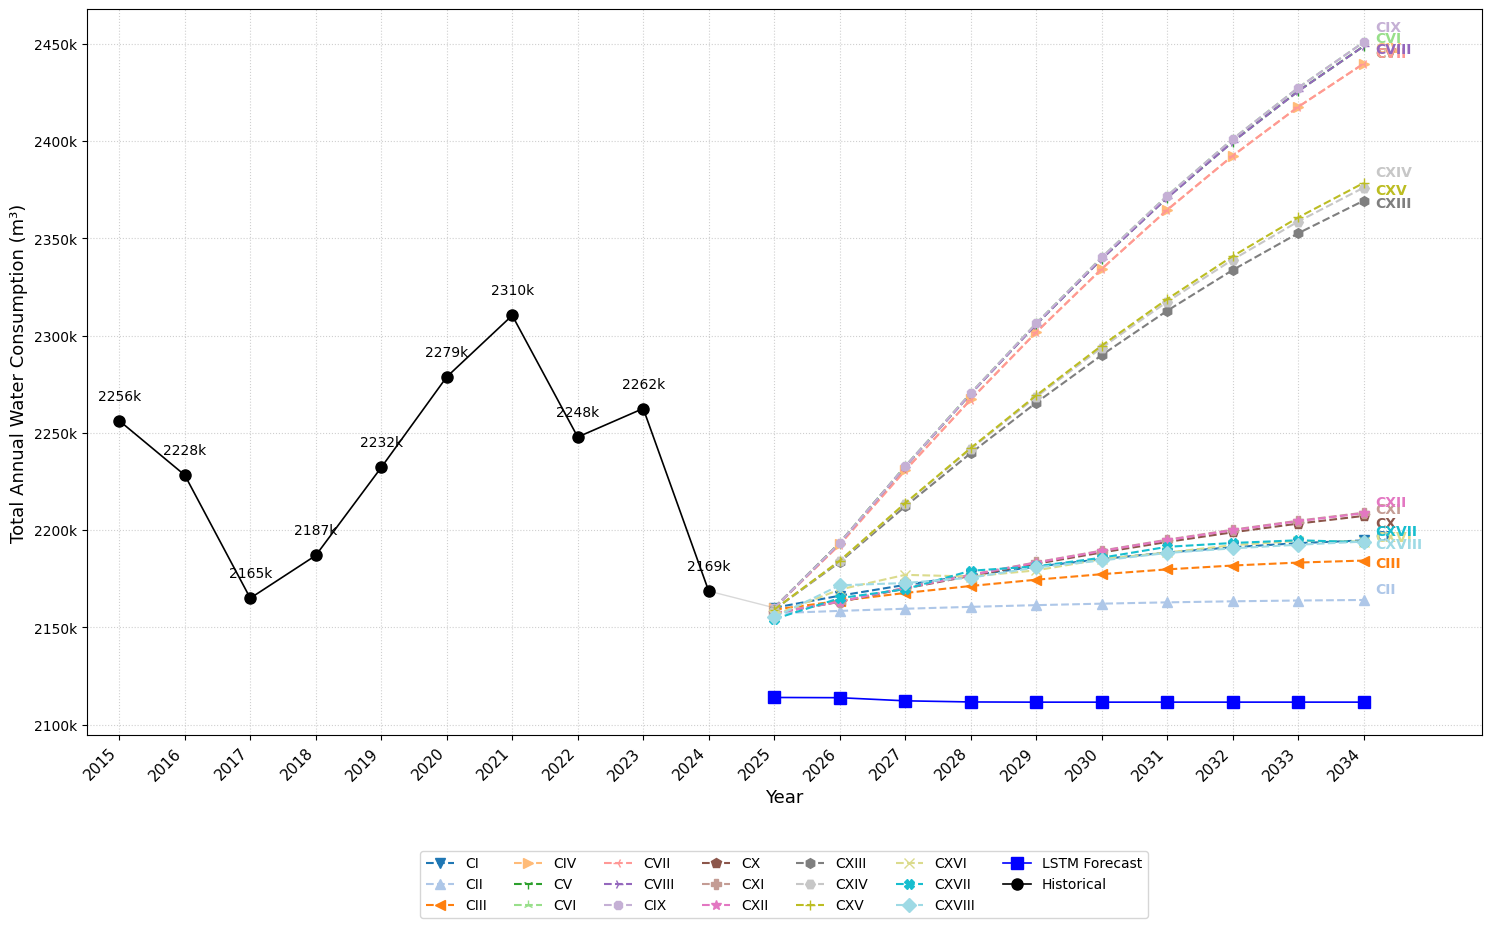

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
# Define the base project directory
BASE_PATH = 'E:\\Projetos\\ABM-WP' 

# Input Filenames
SCENARIO_FILE = 'consumo_previsto_todos_cenarios.csv'
HISTORICAL_FILE = 'Tabela_consumo_Itapua_120m_por_mes.csv'
LSTM_FILE = 'previsoes_futuras_2025_2035.csv'

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-result-simulation-fig10.pdf'

# Search Directories
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')

def aggregate_annually(df, date_col, value_cols):
    """ Aggregates monthly data points into annual totals. """
    df_yearly = df.copy()
    df_yearly['Year'] = df_yearly[date_col].dt.year
    return df_yearly.groupby('Year')[value_cols].sum().reset_index()

def main():
    print("--- Generating Comparative Chart: History vs 18 Scenarios vs LSTM ---")

    # ==========================================
    # 2. Data Loading and Preparation
    # ==========================================
    
    # A. Load Simulation Scenarios
    path_scen = os.path.join(INPUT_DIR_RESULTS, SCENARIO_FILE)
    if not os.path.exists(path_scen): 
        path_scen = os.path.join(INPUT_DIR_INCLUDES, SCENARIO_FILE)
    
    df_scenarios = pd.read_csv(path_scen, sep=';', decimal=',')
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + df_scenarios['Mes'].astype(str) + '-01')
    
    scenario_cols = [c for c in df_scenarios.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    df_scenarios = df_scenarios[df_scenarios['Date'] < pd.to_datetime('2035-01-01')]

    # B. Load Historical Data
    path_hist = os.path.join(INPUT_DIR_INCLUDES, HISTORICAL_FILE)
    df_historical = pd.read_csv(path_hist, sep=';')
    df_historical['Date'] = pd.to_datetime(df_historical['data'])
    df_historical.rename(columns={'consumo': 'Hist'}, inplace=True)

    # C. Load LSTM Forecast
    path_lstm = os.path.join(INPUT_DIR_MODELS, LSTM_FILE)
    df_lstm = pd.read_csv(path_lstm)
    df_lstm['Date'] = pd.to_datetime(df_lstm['Data'], dayfirst=True)
    df_lstm.rename(columns={'Valor Previsto': 'LSTM'}, inplace=True)
    df_lstm = df_lstm[(df_lstm['Date'] >= '2025-01-01') & (df_lstm['Date'] <= '2034-12-31')]

    # Annual Aggregation
    df_hist_sum = aggregate_annually(df_historical, 'Date', ['Hist'])
    df_scen_sum = aggregate_annually(df_scenarios, 'Date', scenario_cols)
    df_lstm_sum = aggregate_annually(df_lstm, 'Date', ['LSTM'])

    # ==========================================
    # 3. Plotting
    # ==========================================
    fig, ax = plt.subplots(figsize=(18, 11))

    # --- A. Transition Connection (2024 to 2025) ---
    last_hist_val = df_hist_sum.iloc[-1]
    # Connects history to the first point of Scenario I for continuity
    first_scen_val = df_scen_sum.loc[df_scen_sum['Year'] == 2025, 'CI_Pop_Uniforme'].values[0]
    ax.plot([last_hist_val['Year'], 2025], [last_hist_val['Hist'], first_scen_val], 
            color='gray', linestyle='-', linewidth=1.0, zorder=8, alpha=0.3)

    # --- B. Plotting 18 Scenarios (Standardized Visibility) ---
    # 18 unique markers to ensure distinction in grayscale or color
    markers_list = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 'p', 'P', '*', 'h', 'H', '+', 'x', 'X', 'D']
    colors = plt.cm.tab20(np.linspace(0, 1, len(scenario_cols)))
    label_offsets = [(8, 0), (8, 5), (8, -5), (8, 8), (8, -8)]
    
    for idx, col in enumerate(scenario_cols):
        scen_id = col.split('_')[0]
        # Forced visibility with alpha=1.0 and uniform thickness
        ax.plot(df_scen_sum['Year'], df_scen_sum[col], label=scen_id, color=colors[idx],
                linestyle='--', linewidth=1.5, alpha=1.0, 
                marker=markers_list[idx % len(markers_list)], markersize=7)
        
        # Position Scenario ID at the end of the line (bold weight)
        last_x = df_scen_sum['Year'].iloc[-1]
        last_y = df_scen_sum[col].iloc[-1]
        ax.annotate(scen_id, (last_x, last_y), xytext=label_offsets[idx % 5], 
                    textcoords="offset points", fontsize=10, color=colors[idx], fontweight='bold')

    # --- C. Plotting LSTM Forecast ---
    ax.plot(df_lstm_sum['Year'], df_lstm_sum['LSTM'], label='LSTM Forecast', color='blue',
            linestyle='-', linewidth=1.2, marker='s', markersize=8, zorder=11)

    # --- D. Plotting Historical Baseline ---
    ax.plot(df_hist_sum['Year'], df_hist_sum['Hist'], label='Historical', color='black',
            linestyle='-', linewidth=1.2, marker='o', markersize=8, zorder=12)

    # Historical values annotation (normal weight)
    for x, y in zip(df_hist_sum['Year'], df_hist_sum['Hist']):
        ax.annotate(f"{y/1000:.0f}k", (x, y), xytext=(0, 15), textcoords="offset points",
                    ha='center', fontsize=10, fontweight='normal', color='black')

    # ==========================================
    # 4. Final Formatting and Export
    # ==========================================
    ax.set_ylabel('Total Annual Water Consumption (m³)', fontsize=13)
    ax.set_xlabel('Year', fontsize=13)
    
    # Axis Tick Configuration
    full_timeline = sorted(list(set(df_hist_sum['Year']).union(set(df_scen_sum['Year']))))
    ax.set_xticks(full_timeline)
    ax.set_xticklabels(full_timeline, rotation=45, ha='right', fontsize=11)
    
    # Format Y-axis to 'k' (thousands) notation
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    ax.set_xlim(full_timeline[0]-0.5, full_timeline[-1]+1.8)
    plt.grid(True, linestyle=':', alpha=0.6)

    # Legend Layout (Fix for fontweight TypeError using 'prop' dictionary)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=7, 
               fontsize=11, frameon=True, prop={'weight': 'normal'})
    
    plt.subplots_adjust(bottom=0.22)

    # Save to PDF
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Comparative chart saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()